#  KV Cache Pruning & Speculative Decoding

## Goals

지금까지의 실습(Pruning, Quantization, Knowledge Distillation)은 **모델의 파라미터 자체를 작게 만드는** 압축 기법이었습니다.
본 실습에서는 축을 바꿔서, **모델 크기는 그대로 둔 채 추론(inference) 시간의 메모리와 지연시간을 줄이는** 두 가지 기법을 다룹니다.

1. **KV Cache Pruning** — 긴 문맥에서 선형적으로 증가하는 KV Cache를 중요한 토큰만 남겨 압축합니다. (lossy)
2. **Speculative Decoding** — 작은 draft 모델이 여러 토큰을 미리 제안하고, target 모델이 한 번의 forward로 검증합니다. (lossless)

두 기법 모두 on-device 환경에서 **memory-bound**인 decoding 단계를 직접 공략한다는 공통점이 있습니다.

## Contents

1. KV Cache의 구조와 메모리 병목 이해 — **[실습 1]**
2. KV Cache Pruning
   - StreamingLLM (제공 예시)
   - H2O: 누적 attention score 기반 heavy hitter — **[실습 2]**
   - SnapKV: observation window + pooling clustering — **[실습 3]**
3. Speculative Decoding 기초 — **[실습 4]**
4. EAGLE 계열: tree drafting과 tree attention 검증 — **[실습 5]**
5. DFlash: block drafter의 marginal 분포로부터 diffusion draft 실습 — **[실습 6]**

In [ ]:
import os
import torch
import transformers
import math
import matplotlib.pyplot as plt
import random
import torch.nn.functional as F
import time

from transformers import AutoTokenizer, AutoModelForCausalLM

DEVICE = "cuda"
DTYPE = torch.float16

MODEL_ID = "Qwen/Qwen3-1.7B"
MODEL_DIR = "/content/models/Qwen3-1.7B"

os.makedirs("/content/models", exist_ok=True)

print("Transformers:", transformers.__version__)
print("GPU:", torch.cuda.get_device_name(0))

Transformers: 5.16.1
GPU: Tesla T4


In [ ]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id=MODEL_ID,
    local_dir=MODEL_DIR,
)

print("Model downloaded to:", MODEL_DIR)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Model downloaded to: /content/models/Qwen3-1.7B


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_DIR,
    dtype=DTYPE,
    attn_implementation="eager",
).to(DEVICE).eval()

print("Model loaded:", MODEL_ID)
print("dtype       :", next(model.parameters()).dtype)

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Model loaded: Qwen/Qwen3-1.7B
dtype       : torch.float16


In [ ]:
config = model.config

n_layers = config.num_hidden_layers
n_q_heads = config.num_attention_heads
n_kv_heads = config.num_key_value_heads
head_dim = getattr(config,"head_dim", config.hidden_size // config.num_attention_heads)

print("Number of layers :", n_layers)
print("Query heads      :", n_q_heads)
print("KV heads         :", n_kv_heads)
print("Head dimension   :", head_dim)
print("GQA group size   :", n_q_heads // n_kv_heads)

Number of layers : 28
Query heads      : 16
KV heads         : 8
Head dimension   : 128
GQA group size   : 2


---

# Part 1. KV Cache의 구조와 메모리 병목

Transformer의 decoding 단계에서는 이미 계산한 Key/Value를 다시 계산하지 않기 위해 **KV Cache**에 저장합니다.
문제는 이 캐시가 **문맥 길이에 정비례해서 커진다**는 점입니다.

$$
\text{KV bytes} = 2 \times B \times L_{\text{layer}} \times H_{kv} \times d_{head} \times S \times \text{dtype bytes}
$$

- 앞의 2는 Key와 Value 두 개
- $H_{kv}$는 **Key/Value head 수**입니다. GQA(Grouped Query Attention)를 쓰는 최신 모델은
  $H_{kv} \ll H_{q}$ 이므로 이 지점에서 이미 캐시가 크게 줄어듭니다.

`5__Quantization_for_LLM.ipynb`에서 살펴본 것처럼 decoding은 memory-bound입니다.
weight를 아무리 양자화해도, 문맥이 길어지면 **캐시 읽기가 새로운 병목**이 됩니다.

## [실습 1] KV Cache 메모리 계산

모델 config로부터 KV Cache가 차지하는 바이트 수를 계산하는 함수를 작성하세요.

In [ ]:
def kv_cache_bytes(config, seq_len, batch_size=1, dtype_bytes=2):
    """
    KV Cache가 차지하는 총 바이트 수를 계산합니다.

    Args:
        config     : transformers의 PretrainedConfig
        seq_len    : 문맥 길이 (토큰 수)
        batch_size : 배치 크기
        dtype_bytes: 원소 하나당 바이트 (FP32 -> 4, FP16/BF16 -> 2)

    Returns:
        int: 총 바이트 수
    """
    nconfig = model.config
    n_layers = config.num_hidden_layers
    n_q_heads = config.num_attention_heads
    n_kv_heads = config.num_key_value_heads
    head_dim = getattr(config,"head_dim", config.hidden_size // config.num_attention_heads)

    # ===== YOUR CODE STARTS HERE =====

    total_bytes =

    # ===== YOUR CODE ENDS HERE =====

    return total_bytes

In [ ]:
for seq_len in [1024, 4096, 16384, 32768]:
    memory_mb = kv_cache_bytes(
        config,
        seq_len,
        dtype_bytes=2,   # FP16
    ) / 1024**2

    print(f"{seq_len:>6} tokens : {memory_mb:8.1f} MB")

  1024 tokens :    112.0 MB
  4096 tokens :    448.0 MB
 16384 tokens :   1792.0 MB
 32768 tokens :   3584.0 MB


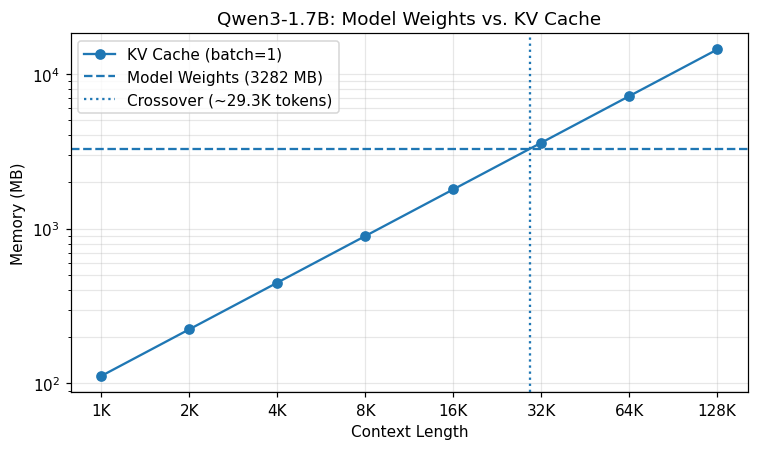

Model weights    : 3281.7 MB
KV cache / token : 112.0 KB
Crossover        : ~29.3K tokens


In [ ]:
# =====================================================================
# Model Weight vs. KV Cache
# =====================================================================

# 실제 로드된 모델의 dtype 크기 (FP16 = 2 bytes)
dtype_bytes = next(model.parameters()).element_size()

# 모델 weight 전체 크기
weight_bytes = sum(
    p.numel() * p.element_size()
    for p in model.parameters()
)
weight_mb = weight_bytes / 1024**2


# ---------------------------------------------------------------------
# Context Length
# ---------------------------------------------------------------------
seq_lens = [
    1 * 1024,
    2 * 1024,
    4 * 1024,
    8 * 1024,
    16 * 1024,
    32 * 1024,
    64 * 1024,
    128 * 1024,
]

seq_labels = [
    "1K", "2K", "4K", "8K",
    "16K", "32K", "64K", "128K"
]


# ---------------------------------------------------------------------
# KV Cache Memory
# ---------------------------------------------------------------------
kv_mb = [
    kv_cache_bytes(
        model.config,
        seq_len=s,
        dtype_bytes=dtype_bytes,
    ) / 1024**2
    for s in seq_lens
]


# KV Cache가 모델 weight보다 커지는 실제 context length
kv_bytes_per_token = kv_cache_bytes(
    model.config,
    seq_len=1,
    dtype_bytes=dtype_bytes,
)

cross_seq_len = math.ceil(
    weight_bytes / kv_bytes_per_token
)


# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 4.2), dpi=110)

plt.plot(
    seq_lens,
    kv_mb,
    "o-",
    label="KV Cache (batch=1)",
)

plt.axhline(
    weight_mb,
    linestyle="--",
    label=f"Model Weights ({weight_mb:.0f} MB)",
)

plt.axvline(
    cross_seq_len,
    linestyle=":",
    label=f"Crossover (~{cross_seq_len / 1024:.1f}K tokens)",
)

plt.xscale("log", base=2)
plt.yscale("log")

# x축을 1K, 2K, 4K ... 형태로 표시
plt.xticks(seq_lens, seq_labels)

plt.xlabel("Context Length")
plt.ylabel("Memory (MB)")
plt.title(
    f"{MODEL_ID.split('/')[-1]}: Model Weights vs. KV Cache"
)

plt.grid(alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------
# Summary
# ---------------------------------------------------------------------
print(f"Model weights    : {weight_mb:.1f} MB")
print(f"KV cache / token : {kv_bytes_per_token / 1024:.1f} KB")
print(f"Crossover        : ~{cross_seq_len / 1024:.1f}K tokens")

---

# Part 2. KV Cache Pruning

KV Cache Pruning(= KV Cache Compression, eviction)은 **중요도가 낮은 토큰의 Key/Value를 버려서**
캐시 크기를 예산(budget) 이내로 유지하는 기법입니다.

방법들은 결국 두 가지 선택지의 조합입니다.

| 축 | 선택지 |
|---|---|
| **무엇을 남길 것인가 (scoring)** | 위치 기반(StreamingLLM) / 누적 attention(H2O) / 관측 윈도우 attention(SnapKV) |
| **얼마나 남길 것인가 (budget)** | 레이어 균등(H2O, SnapKV) / 레이어별 차등(PyramidKV) / head별 차등(Ada-KV) |

본 실습에서는 **scoring 축**에 집중합니다. 아래 `KVPress` 인터페이스에서 `score()` 함수만 바꿔 끼우면
세 방법이 완전히 동일한 조건에서 비교됩니다.

> 구현 참고: `github.com/NVIDIA/kvpress`, `github.com/Zefan-Cai/KVCache-Factory`

In [ ]:
# =====================================================================
# 2-1. 평가용 태스크: Passkey Retrieval
# =====================================================================

FILLERS = [
    "The weather was clear in the morning.",
    "A small boat crossed the river.",
    "The library closes at six in the evening.",
    "Several people were waiting at the station.",
    "The meeting started after lunch.",
    "A red bicycle was parked near the building.",
    "The coffee shop was crowded in the afternoon.",
    "The package arrived earlier than expected.",
]

def make_passkey_prompt(tokenizer, n_filler=200, depth=0.5, key=None, seed=0):
    """depth에 가까운 token 위치에 passkey를 삽입합니다."""
    rng = random.Random(seed)
    key = key or str(rng.randint(10000, 99999))

    filler = [rng.choice(FILLERS) for _ in range(n_filler)]

    needle = (
        f"IMPORTANT: The secret pass key is {key}. "
        f"Remember the exact five-digit number {key}."
    )

    # 각 filler의 token 길이를 이용해 삽입 위치 결정
    lengths = [
        len(tokenizer(s, add_special_tokens=False).input_ids)
        for s in filler
    ]

    target = sum(lengths) * depth
    total = 0
    pos = 0

    for i, length in enumerate(lengths):
        if total >= target:
            pos = i
            break
        total += length
    else:
        pos = len(filler)

    filler.insert(pos, needle)
    body = " ".join(filler)

    msg = [{
        "role": "user",
        "content": (
            "Read the following text carefully and remember the secret pass key.\n\n"
            + body +
            "\n\nWhat is the secret pass key? Answer with the five-digit number."
        )
    }]

    text = tokenizer.apply_chat_template(
        msg,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )

    ids = tokenizer(text, return_tensors="pt").input_ids.to(DEVICE)
    return ids, key


ids, key = make_passkey_prompt(tokenizer)

print("Prompt length :", ids.shape[1], "tokens")
print("Passkey       :", key)

Prompt length : 1623 tokens
Passkey       : 60494


In [ ]:
# =====================================================================
# Full KV Baseline: 위치별 확인
# =====================================================================
@torch.no_grad()
def generate_full_kv(model, tokenizer, input_ids, max_new_tokens=12):
    output = model.generate(
        input_ids,
        max_new_tokens=max_new_tokens,
        do_sample=False,          # greedy decoding
        use_cache=True,
    )

    # 입력 prompt를 제외하고 새로 생성된 token만 가져옴
    generated = output[:, input_ids.shape[1]:]

    return tokenizer.decode(
        generated[0],
        skip_special_tokens=True,
    )


for depth in [0.1, 0.3, 0.5, 0.7, 0.9]:
    ids, key = make_passkey_prompt(tokenizer, depth=depth, seed=2)

    text = generate_full_kv(
        model, tokenizer, ids,
        max_new_tokens=12,
    )

    print(
        f"depth={depth:.1f} | "
        f"answer={key} | "
        f"{'O' if key in text else 'X'} | "
        f"{text.strip()}"
    )

depth=0.1 | answer=17412 | O | The secret pass key is **17412**
depth=0.3 | answer=17412 | O | The secret pass key is **17412**
depth=0.5 | answer=17412 | O | The secret pass key is **17412**
depth=0.7 | answer=17412 | O | The secret pass key is **17412**
depth=0.9 | answer=17412 | O | The secret pass key is **17412**


In [ ]:
# =====================================================================
# 2-2. KV Cache Pruning 공통 함수
#   score_fn만 바꿔 StreamingLLM / H2O / SnapKV를 비교합니다.
# =====================================================================

@torch.no_grad()
def prune_and_decode(model, input_ids, score_fn, budget,
                     use_attn=False, max_new_tokens=12):

    # Prefill
    out = model(input_ids, use_cache=True, output_attentions=use_attn)
    cache, logits = out.past_key_values, out.logits[:, -1]

    n_kv = model.config.num_key_value_heads
    group = model.config.num_attention_heads // n_kv

    # Layer별 KV pruning
    for i, layer in enumerate(cache.layers):
        attn_kv = None

        if use_attn:
            attn = out.attentions[i]
            B, _, Q, K = attn.shape

            # GQA: 같은 KV head를 공유하는 Q head들의 attention 합산
            attn_kv = attn.view(B, n_kv, group, Q, K).sum(2)

        scores = score_fn(attn_kv, layer, budget)

        keep = scores.topk(budget, dim=-1).indices.sort(-1).values
        idx = keep.unsqueeze(-1).expand(-1, -1, -1, layer.keys.shape[-1])

        layer.keys   = layer.keys.gather(2, idx)
        layer.values = layer.values.gather(2, idx)

    # 압축된 KV Cache로 greedy decoding
    generated = []
    pos = input_ids.shape[1]

    for _ in range(max_new_tokens):
        token = logits.argmax(-1, keepdim=True)
        generated.append(token.item())

        out = model(
            input_ids=token,
            past_key_values=cache,
            use_cache=True,
            position_ids=torch.tensor([[pos]], device=DEVICE),
            cache_position=torch.tensor([cache.get_seq_length()], device=DEVICE),
        )

        logits = out.logits[:, -1]
        pos += 1

    return generated, cache

## StreamingLLM like KV Cache Pruning

> Efficient Streaming Language Models with Attention Sinks (ICLR 2024)

StreamingLLM은 **맨 앞의 일부 attention sink token과 최근 token을 유지**하는 방식으로 KV cache를 관리합니다.

여기서는 StreamingLLM류의 pruning 방식을 간단히 구현하여, **초기 sink token과 최근 token만 남겼을 때의 동작을 테스트**합니다.

각 token의 위치를 score로 사용해 최근 token일수록 높은 점수를 주고, sink token은 항상 유지되도록 설정합니다.


In [ ]:
# =====================================================================
# 2-3. StreamingLLM Score
#   맨 앞 sink token + 최근 token을 유지합니다.
# =====================================================================

def streaming_score(attn_kv, layer, budget, n_sink=4):
    B, H, K, _ = layer.keys.shape

    # 최근 token일수록 높은 점수: 0, 1, 2, ..., K-1
    scores = torch.arange(K, device=DEVICE).float().repeat(B, H, 1)

    # 처음 n_sink개 token은 무조건 유지
    scores[:, :, :n_sink] = float("inf")

    return scores

In [ ]:
# =====================================================================
# 2-4. StreamingLLM: Passkey 위치별 평가
# =====================================================================

for depth in [0.1, 0.3, 0.5, 0.7, 0.9]:

    ids, key = make_passkey_prompt(
        tokenizer,
        depth=depth,
        seed=2,
    )

    tokens, cache = prune_and_decode(
        model,
        ids,
        score_fn=streaming_score,
        budget=256,
        use_attn=False,
    )

    text = tokenizer.decode(tokens, skip_special_tokens=True, enable_thinking=False)

    print(
        f"depth={depth:.1f} | "
        f"answer={key} | "
        f"{'O' if key in text else 'X'} | "
        f"{text.strip()}"
    )

depth=0.1 | answer=17412 | X | The secret pass key is **12345**
depth=0.3 | answer=17412 | X | The secret pass key is **12345**
depth=0.5 | answer=17412 | X | The secret pass key is **12345**
depth=0.7 | answer=17412 | X | The secret pass key is **12345**
depth=0.9 | answer=17412 | O | The secret pass key is **17412**


## [실습 3] H2O (Heavy-Hitter Oracle)

> H2O: Heavy-Hitter Oracle for Efficient Generative Inference of LLMs (NeurIPS 2023)

관찰: attention 행렬은 매우 희소하며, **일부 토큰이 모든 query로부터 지속적으로 큰 attention을 받습니다.**
이런 토큰을 heavy hitter라고 부르고, 이들과 최근 토큰만 남깁니다.

중요도는 **모든 query 위치에 대한 attention의 누적 합**으로 정의합니다.

$$
\text{score}(j) = \sum_{i} A_{ij}
$$

아래 빈칸을 채워 `H2OPress`를 완성하세요.

In [ ]:
# =====================================================================
# 2-5. H2O Score
#   전체 query의 attention을 누적하여 heavy-hitter token을 찾습니다.
# =====================================================================

def h2o_score(attn_kv, layer, budget):

    recent_size = budget//2
    ############실습코드 시작#############
    # 전체 query의 attention 누적
    scores =

    # 최근 recent_size개 token은 항상 보존
    scores[..., -recent_size:] = float("inf")
    ############실습코드 끝##############

    return scores

In [ ]:
# =====================================================================
# H2O: Passkey 위치별 평가
# =====================================================================

for depth in [0.1, 0.3, 0.5, 0.7, 0.9]:

    ids, key = make_passkey_prompt(
        tokenizer,
        depth=depth,
        seed=2,
    )

    tokens, _ = prune_and_decode(
        model,
        ids,
        score_fn=h2o_score,
        budget=256,
        use_attn=True,
    )

    text = tokenizer.decode(tokens, skip_special_tokens=True)

    print(
        f"depth={depth:.1f} | "
        f"answer={key} | "
        f"output={text.strip()} | "
        f"{'O' if key in text else 'X'}"
    )

depth=0.1 | answer=17412 | output=The secret pass key is **17412** | O
depth=0.3 | answer=17412 | output=The secret pass key is **17412** | O
depth=0.5 | answer=17412 | output=The secret pass key is **17412** | O
depth=0.7 | answer=17412 | output=The secret pass key is **12345** | X
depth=0.9 | answer=17412 | output=The secret pass key is **12345** | X


### H2O의 구조적 편향

H2O의 점수는 causal mask 때문에 **앞쪽 토큰일수록 더 많은 query로부터 합산**됩니다.
즉 위치 $j$는 $N-j$개의 query에서만 attention을 받으므로, 단순 합산은
**뒤쪽 토큰에 불리**한 방향으로 왜곡됩니다(원 논문도 이 점을 지적합니다).

아래에서 정규화 유무를 비교해 봅니다.

In [ ]:
# =====================================================================
# H2O의 구조적 편향: H2O vs H2O-Norm
# =====================================================================

def h2o_norm_score(attn_kv, layer, budget):
    """누적 attention을 실제로 attend된 query 개수로 나눈 변형."""
    B, H, Q, K = attn_kv.shape
    recent_size = budget // 2

    # 전체 query의 attention 누적
    scores = attn_kv.sum(dim=-2)

    # token j가 실제로 attention을 받을 수 있었던 query 수
    count = torch.arange(
        K, 0, -1,
        device=attn_kv.device,
        dtype=scores.dtype,
    )

    # 최근 token은 항상 보존
    scores[..., -recent_size:] = float("inf")

    return scores / count.view(1, 1, K)

In [ ]:
# =====================================================================
# H2O-Norm: Passkey 위치별 평가
# =====================================================================

for depth in [0.1, 0.3, 0.5, 0.7, 0.9]:

    ids, key = make_passkey_prompt(
        tokenizer,
        depth=depth,
        seed=2,
    )

    tokens, _ = prune_and_decode(
        model,
        ids,
        score_fn=h2o_norm_score,
        budget=256,
        use_attn=True,
    )

    text = tokenizer.decode(tokens, skip_special_tokens=True)

    print(
        f"depth={depth:.1f} | "
        f"answer={key} | "
        f"output={text.strip()} | "
        f"{'O' if key in text else 'X'}"
    )

depth=0.1 | answer=17412 | output=The secret pass key is **17412** | O
depth=0.3 | answer=17412 | output=The secret pass key is **17412** | O
depth=0.5 | answer=17412 | output=The secret pass key is **17412** | O
depth=0.7 | answer=17412 | output=The secret pass key is **17411** | X
depth=0.9 | answer=17412 | output=The secret pass key is **17412** | O


## [실습 4] SnapKV

> SnapKV: LLM Knows What You are Looking for Before Generation (NeurIPS 2024)

SnapKV의 두 가지 핵심 아이디어입니다.

1. **Observation window** — 앞으로 생성할 토큰이 무엇을 볼지는, 프롬프트 **맨 끝 몇십 개 query**가
   이미 알려줍니다. 전체 query가 아니라 마지막 `window`개 query의 attention만 사용합니다.
   (H2O의 recency 편향 문제도 자연스럽게 사라집니다.)
2. **Pooling clustering** — 점수에 1D max pooling을 적용한 뒤 top-k를 고릅니다.
   이렇게 하면 중요한 토큰 **주변 문맥이 통째로** 살아남아, 잘린 문장 조각만 남는 현상을 막습니다.

아래 빈칸을 채워 `SnapKVPress`를 완성하세요.

In [ ]:
# =====================================================================
# 2-7. SnapKV Score
#   마지막 observation window의 attention을 사용하고,
#   max pooling으로 인접 token의 중요도를 함께 반영합니다.
# =====================================================================

def snapkv_score(attn_kv, layer, budget, window=32, kernel=7):
    B, H, Q, K = attn_kv.shape
    w = min(window, Q)

    ########################실습코드 시작#########################

    # TODO 1
    # 마지막 w개의 query가 각 KV token에 준 attention을 합산하세요.
    # Hint: attn_kv shape = [B, H, Q, K]
    scores =

    # 각 token 주변 kernel 범위에서 가장 큰 score를 가져옵니다.
    half = kernel // 2
    pooled_scores = scores.clone()

    for j in range(K):
        start = max(0, j - half)
        end   = min(K, j + half + 1)

        # TODO 2
        # Hint: start ~ end 위치 중 최대 score
        pooled_scores[:, :, j] =

    scores = pooled_scores

    # Observation window는 항상 유지
    scores[:, :, -w:] = float("inf")
    ########################실습코드 끝#########################

    return scores

In [ ]:
for depth in [0.1, 0.3, 0.5, 0.7, 0.9]:

    ids, key = make_passkey_prompt(
        tokenizer,
        depth=depth,
        seed=2,
    )

    tokens, _ = prune_and_decode(
        model,
        ids,
        score_fn=snapkv_score,
        budget=256,
        use_attn=True,
    )

    text = tokenizer.decode(tokens, skip_special_tokens=True)

    print(
        f"depth={depth:.1f} | "
        f"answer={key} | "
        f"output={text.strip()} | "
        f"{'O' if key in text else 'X'}"
    )

depth=0.1 | answer=17412 | output=The secret pass key is **17412** | O
depth=0.3 | answer=17412 | output=The secret pass key is **17412** | O
depth=0.5 | answer=17412 | output=The secret pass key is **17412** | O
depth=0.7 | answer=17412 | output=The secret pass key is **17412** | O
depth=0.9 | answer=17412 | output=The secret pass key is **17412** | O


In [ ]:
# =====================================================================
# 2-9. 통합 비교: Budget Sweep
# =====================================================================

DEPTHS = [0.1, 0.3, 0.5, 0.7, 0.9]
BUDGETS = [512, 256, 128, 64]

METHODS = [
    ("StreamingLLM", streaming_score, False),
    ("H2O",          h2o_score,       True),
    ("SnapKV",       snapkv_score,    True),
]


def passkey_accuracy(score_fn, budget, use_attn):
    """5개 위치에서 passkey retrieval 성공률을 계산합니다."""
    correct = 0

    for depth in DEPTHS:
        ids, key = make_passkey_prompt(tokenizer, depth=depth, seed=2)

        tokens, _ = prune_and_decode(
            model,
            ids,
            score_fn=score_fn,
            budget=budget,
            use_attn=use_attn,
        )

        text = tokenizer.decode(tokens, skip_special_tokens=True)
        correct += int(key in text)

    return correct / len(DEPTHS)


results = {}

for name, score_fn, use_attn in METHODS:
    accs = []

    for budget in BUDGETS:
        acc = passkey_accuracy(score_fn, budget, use_attn)
        accs.append(acc)

        print(
            f"{name:>13} | "
            f"budget={budget:>3} | "
            f"accuracy={acc*100:5.1f}%"
        )

    results[name] = accs

 StreamingLLM | budget=512 | accuracy= 40.0%
 StreamingLLM | budget=256 | accuracy= 20.0%
 StreamingLLM | budget=128 | accuracy=  0.0%
 StreamingLLM | budget= 64 | accuracy=  0.0%
          H2O | budget=512 | accuracy=100.0%
          H2O | budget=256 | accuracy= 60.0%
          H2O | budget=128 | accuracy= 20.0%
          H2O | budget= 64 | accuracy=  0.0%
       SnapKV | budget=512 | accuracy=100.0%
       SnapKV | budget=256 | accuracy=100.0%
       SnapKV | budget=128 | accuracy=100.0%
       SnapKV | budget= 64 | accuracy= 80.0%


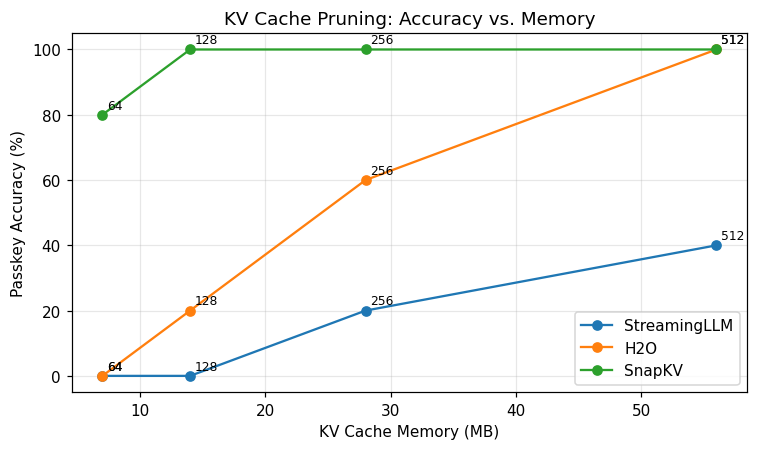

In [ ]:
# =====================================================================
# 정확도 vs KV Cache 메모리
# =====================================================================

dtype_bytes = next(model.parameters()).element_size()

# budget별 KV Cache 메모리
mems = [
    kv_cache_bytes(
        model.config,
        seq_len=budget,
        dtype_bytes=dtype_bytes,
    ) / 1024**2
    for budget in BUDGETS
]

plt.figure(figsize=(7, 4.2), dpi=110)

for name, accs in results.items():
    plt.plot(mems, [a * 100 for a in accs], "o-", label=name)

    # 각 점에 budget 표시
    for mem, acc, budget in zip(mems, accs, BUDGETS):
        plt.annotate(
            str(budget),
            (mem, acc * 100),
            fontsize=8,
            xytext=(3, 4),
            textcoords="offset points",
        )

plt.xlabel("KV Cache Memory (MB)")
plt.ylabel("Passkey Accuracy (%)")
plt.title("KV Cache Pruning: Accuracy vs. Memory")

plt.grid(alpha=0.3)
plt.legend()
plt.ylim(-5, 105)
plt.tight_layout()
plt.show()

### Part 2 정리

- **StreamingLLM**은 attention을 전혀 계산하지 않아 가장 값싸지만, **중간 문맥을 통째로 버리기 때문에**
  passkey가 앞/중간에 있으면 실패합니다. 스트리밍 대화처럼 "최근 문맥만 중요한" 상황에 적합합니다.
- **H2O**는 누적 attention으로 중간의 중요한 토큰도 잡아내지만, causal mask에 의한 recency 편향이 있습니다.
- **SnapKV**는 observation window로 "앞으로 무엇을 볼지"를 직접 추정하고 pooling으로 문맥 덩어리를 보존해
  같은 예산에서 가장 안정적입니다.

eviction 계열은 **한 번 버린 토큰을 되살릴 수 없다**는 근본적 한계가 있습니다. 이와 직교하는 방향으로
KV 양자화(KIVI), 저랭크 분해(Palu), 전체 캐시를 유지한 채 일부만 읽는 sparse attention(Quest),
레이어/head별 예산 배분(PyramidKV, Ada-KV) 등이 연구되고 있습니다.

In [ ]:
# =====================================================================
# KV Cache Pruning 종료: VRAM 정리
# =====================================================================

import gc

del model

# 이전 실험에서 남아있는 KV Cache 제거
if "cache" in globals():
    del cache
if "_" in globals():
    del _

gc.collect()
torch.cuda.empty_cache()

print("KV pruning 모델 해제 완료")

KV pruning 모델 해제 완료
